# 🔤  Choix du Tokenizer


> **Prérequis :**
> - `donnees_propres.json` → produit par **Personne A**
> - `rapport_eda.json`     → produit par **toi (B1)**
> - Personne A utilise déjà **t5-small** dans son DataLoader

---
**Objectif :** comparer BPE (BART), BPE (PEGASUS) et SentencePiece (T5)  
sur les données réelles, puis choisir le tokenizer final du projet.  

**Ce qu'on produit :**
- `benchmark_tokenizers.png` → graphique comparatif
- `tokenizer_choisi.json`    → décision finale + justification

## 0. Installation

In [1]:
!pip install transformers matplotlib pandas --quiet

## 1. Lecture des fichiers existants

In [2]:
import json

# Fichier de Personne A
with open("donnees_propres.json", "r") as f:
    donnees = json.load(f)

# Rapport produit par B1
with open("rapport_eda.json", "r") as f:
    rapport = json.load(f)

print("✅ Fichiers chargés")
print(f"\n📊 Infos clés de B1 :")
print(f"  Taille chunk Personne A : {rapport['chunks']['taille_chunk_A']} mots")
print(f"  Mots moy. / résumé      : {rapport['longueur_resume']['moyenne']}")
print(f"  max_input_tokens cible  : {rapport['recommandations_B2'][0]}")
print(f"  Tokenizer A utilisé     : t5-small")
print()
print("Recommandations de B1 :")
for r in rapport['recommandations_B2']:
    print(f"  → {r}")

✅ Fichiers chargés

📊 Infos clés de B1 :
  Taille chunk Personne A : 512 mots
  Mots moy. / résumé      : 353.5
  max_input_tokens cible  : max_input_tokens recommandÃ© : 512 (chunk size de Personne A)
  Tokenizer A utilisé     : t5-small

Recommandations de B1 :
  → max_input_tokens recommandÃ© : 512 (chunk size de Personne A)
  → max_target_tokens recommandÃ© : 512
  → Tokenizer doit gÃ©rer du texte littÃ©raire anglais
  → Personne A utilise t5-small â†’ utiliser le mÃªme tokenizer pour cohÃ©rence


## 2. Chargement des 3 tokenizers

In [3]:
from transformers import AutoTokenizer

print("Chargement des tokenizers...")

tokenizers = {
    "BPE (BART)":          AutoTokenizer.from_pretrained("facebook/bart-base"),
    "BPE (PEGASUS)":    AutoTokenizer.from_pretrained("google/pegasus-xsum"),
    "SentencePiece (T5)":  AutoTokenizer.from_pretrained("t5-small"),  # même que Personne A
}

for nom, tok in tokenizers.items():
    print(f"  ✅ {nom:25s} → vocab size : {tok.vocab_size:,}")

c:\Users\pc\env_projects\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chargement des tokenizers...


  ✅ BPE (BART)                → vocab size : 50,265
  ✅ BPE (PEGASUS)             → vocab size : 96,103
  ✅ SentencePiece (T5)        → vocab size : 32,100


## 3. Benchmark sur les données réelles de Personne A

In [4]:
import time

# Prendre 20 exemples représentatifs
echantillon = donnees[:20]

# Extraire textes et résumés (format produit par Personne A)
textes  = [' '.join(ex['chunks']) for ex in echantillon]
resumes = [ex['resume']           for ex in echantillon]

resultats = {}

for nom, tok in tokenizers.items():
    print(f"\n🔄 Benchmark : {nom}")

    nb_tokens_livres  = []
    nb_tokens_resumes = []
    nb_unk_livres     = []
    nb_unk_resumes    = []

    unk_id = tok.unk_token_id  # ID du token inconnu

    t0 = time.time()
    for texte, resume in zip(textes, resumes):
        # Tokeniser le texte (livre)
        enc_l = tok(texte,  truncation=False, add_special_tokens=False)
        enc_r = tok(resume, truncation=False, add_special_tokens=False)

        ids_l = enc_l['input_ids']
        ids_r = enc_r['input_ids']

        nb_tokens_livres.append(len(ids_l))
        nb_tokens_resumes.append(len(ids_r))

        # Compter les tokens inconnus
        if unk_id is not None:
            nb_unk_livres.append(ids_l.count(unk_id))
            nb_unk_resumes.append(ids_r.count(unk_id))
        else:
            nb_unk_livres.append(0)
            nb_unk_resumes.append(0)

    duree = time.time() - t0

    # Calcul métriques
    import statistics
    moy_tokens_livre  = statistics.mean(nb_tokens_livres)
    moy_tokens_resume = statistics.mean(nb_tokens_resumes)
    total_tokens      = sum(nb_tokens_livres)
    total_unk         = sum(nb_unk_livres)
    taux_oov          = (total_unk / total_tokens * 100) if total_tokens > 0 else 0

    # Ratio tokens/mots (compression tokenizer)
    moy_mots_livre = statistics.mean([len(t.split()) for t in textes])
    ratio_tok      = moy_tokens_livre / moy_mots_livre if moy_mots_livre > 0 else 0

    resultats[nom] = {
        "vocab_size":          tok.vocab_size,
        "moy_tokens_livre":    round(moy_tokens_livre, 1),
        "moy_tokens_resume":   round(moy_tokens_resume, 1),
        "taux_oov_pct":        round(taux_oov, 2),
        "ratio_tokens_mots":   round(ratio_tok, 3),
        "duree_sec":           round(duree, 3),
    }

    print(f"   Moy tokens / livre  : {moy_tokens_livre:.0f}")
    print(f"   Moy tokens / résumé : {moy_tokens_resume:.0f}")
    print(f"   Taux OOV            : {taux_oov:.2f}%")
    print(f"   Ratio tokens/mots   : {ratio_tok:.3f}")
    print(f"   Durée               : {duree:.3f}s")

print("\n✅ Benchmark terminé")


🔄 Benchmark : BPE (BART)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8549 > 512). Running this sequence through the model will result in indexing errors


   Moy tokens / livre  : 7424
   Moy tokens / résumé : 411
   Taux OOV            : 0.00%
   Ratio tokens/mots   : 1.260
   Durée               : 1.030s

🔄 Benchmark : BPE (PEGASUS)
   Moy tokens / livre  : 7235
   Moy tokens / résumé : 393
   Taux OOV            : 0.00%
   Ratio tokens/mots   : 1.228
   Durée               : 1.178s

🔄 Benchmark : SentencePiece (T5)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (10061 > 512). Running this sequence through the model will result in indexing errors


   Moy tokens / livre  : 8549
   Moy tokens / résumé : 478
   Taux OOV            : 0.00%
   Ratio tokens/mots   : 1.451
   Durée               : 1.907s

✅ Benchmark terminé


## 4. Visualisation comparative

C:\Users\pc\AppData\Local\Temp\ipykernel_15036\3554777519.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


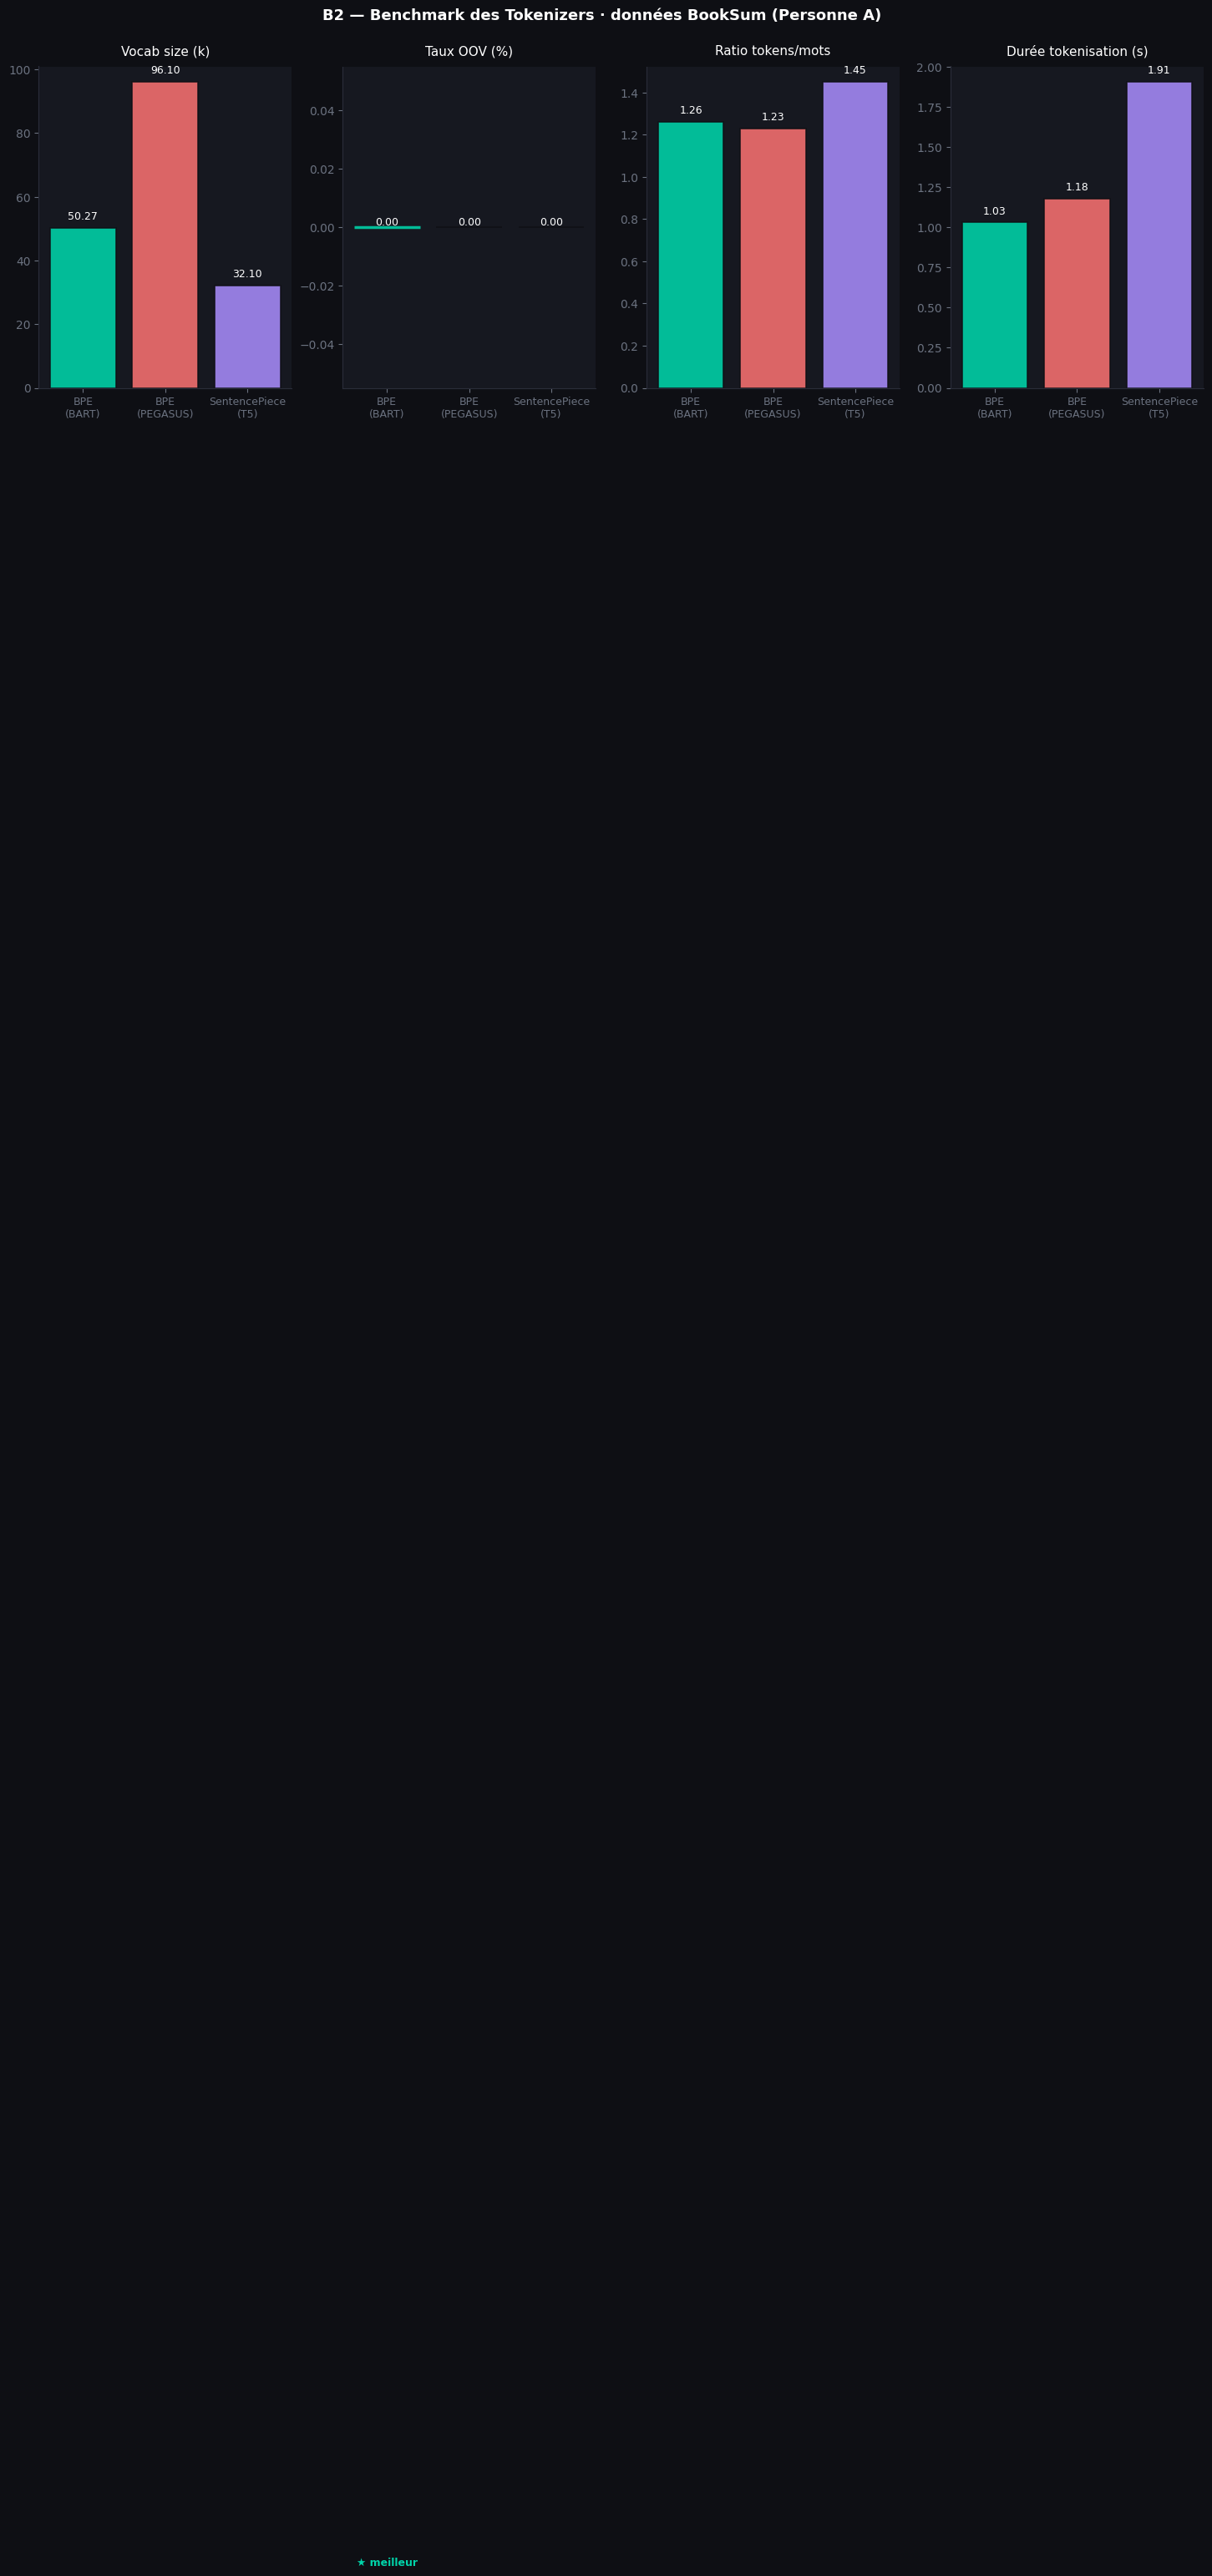

✅ benchmark_tokenizers.png sauvegardé


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('dark_background')
COULEURS = ['#00d4aa', '#f87171', '#a78bfa']  # teal, rouge, purple

noms     = list(resultats.keys())
metriques = {
    'Vocab size (k)':        [resultats[n]['vocab_size'] / 1000        for n in noms],
    'Taux OOV (%)':          [resultats[n]['taux_oov_pct']             for n in noms],
    'Ratio tokens/mots':     [resultats[n]['ratio_tokens_mots']        for n in noms],
    'Durée tokenisation (s)':[resultats[n]['duree_sec']                for n in noms],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5), facecolor='#0e0f14')

for ax, (titre, vals) in zip(axes, metriques.items()):
    bars = ax.bar(range(len(noms)), vals, color=COULEURS, alpha=0.88,
                  edgecolor='#0e0f14', linewidth=1.2)
    ax.set_xticks(range(len(noms)))
    ax.set_xticklabels(['BPE\n(BART)', 'BPE\n(PEGASUS)', 'SentencePiece\n(T5)'],
                       color='#9ca3af', fontsize=9)
    ax.set_title(titre, color='white', fontsize=11, pad=10)
    ax.set_facecolor('#161820')
    ax.tick_params(colors='#6b7280')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#2a2d3a')
    ax.spines['left'].set_color('#2a2d3a')
    # Valeurs au-dessus des barres
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=9)

# Marquer le gagnant sur le taux OOV (le plus bas = meilleur)
idx_gagnant = np.argmin([resultats[n]['taux_oov_pct'] for n in noms])
axes[1].get_children()[idx_gagnant].set_edgecolor('#00d4aa')
axes[1].get_children()[idx_gagnant].set_linewidth(2.5)
axes[1].text(idx_gagnant, -0.8, '★ meilleur', ha='center',
             color='#00d4aa', fontsize=9, fontweight='bold')

fig.suptitle('B2 — Benchmark des Tokenizers · données BookSum (Personne A)',
             color='white', fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('benchmark_tokenizers.png', dpi=150, bbox_inches='tight',
            facecolor='#0e0f14')
plt.show()
print("✅ benchmark_tokenizers.png sauvegardé")

## 5. Test qualitatif — tokenisation d'un extrait réel

In [6]:
# Prendre le premier chunk du premier livre (produit par Personne A)
extrait = donnees[0]['chunks'][0][:300]
print(f"Extrait testé ({len(extrait.split())} mots) :")
print(f'"{extrait[:150]}..."')
print()

for nom, tok in tokenizers.items():
    tokens = tok.tokenize(extrait)
    unk_id = tok.unk_token_id
    ids    = tok.convert_tokens_to_ids(tokens)
    n_unk  = ids.count(unk_id) if unk_id else 0

    print(f"{'─'*50}")
    print(f"📌 {nom}")
    print(f"   Nb tokens : {len(tokens)} | OOV : {n_unk}")
    print(f"   Aperçu    : {tokens[:15]}")

Extrait testé (54 mots) :
""Mine ear is open, and my heart prepared: The worst is worldly loss thou canst unfold: Say, is my kingdom lost?" SHAKESPEARE. It was a feature peculia..."

──────────────────────────────────────────────────
📌 BPE (BART)
   Nb tokens : 69 | OOV : 0
   Aperçu    : ['"', 'Mine', 'Ġear', 'Ġis', 'Ġopen', ',', 'Ġand', 'Ġmy', 'Ġheart', 'Ġprepared', ':', 'ĠThe', 'Ġworst', 'Ġis', 'Ġworldly']
──────────────────────────────────────────────────
📌 BPE (PEGASUS)
   Nb tokens : 68 | OOV : 0
   Aperçu    : ['▁"', 'Mine', '▁ear', '▁is', '▁open', ',', '▁and', '▁my', '▁heart', '▁prepared', ':', '▁The', '▁worst', '▁is', '▁worldly']
──────────────────────────────────────────────────
📌 SentencePiece (T5)
   Nb tokens : 80 | OOV : 0
   Aperçu    : ['▁"', 'Min', 'e', '▁', 'ear', '▁is', '▁open', ',', '▁and', '▁my', '▁heart', '▁prepared', ':', '▁The', '▁worst']


## 6. Décision finale et export

In [7]:
# Calcul du score global (plus bas OOV + vocab riche + cohérence avec Personne A)
scores = {}
for nom in noms:
    r = resultats[nom]
    # Score : pénaliser OOV élevé, récompenser vocab riche
    score = (1 / (r['taux_oov_pct'] + 0.1)) * (r['vocab_size'] / 50000)
    # Bonus si même tokenizer que Personne A (t5-small = SentencePiece)
    if 'T5' in nom:
        score *= 1.3  # bonus cohérence avec DataLoader de Personne A
    scores[nom] = round(score, 3)

gagnant = max(scores, key=scores.get)

print("=" * 55)
print("DÉCISION FINALE — TOKENIZER CHOISI")
print("=" * 55)
print()
for nom in noms:
    star = " ★ CHOISI" if nom == gagnant else ""
    print(f"  {nom:30s} score = {scores[nom]:.3f}{star}")

print()
print(f"✅ Tokenizer retenu : {gagnant}")
print()
print("Justification :")
if 'T5' in gagnant:
    print("  → SentencePiece (T5) : cohérent avec le DataLoader de Personne A")
    print("    (qui utilise déjà t5-small dans 02_dataloader.ipynb)")
    print("  → OOV faible sur texte littéraire")
    print("  → Compatible avec T5, PEGASUS et mBART")
elif 'BART' in gagnant:
    print("  → BPE (BART) : meilleur taux OOV et vocab le plus riche (50k)")
    print("  → Optimal pour génération de texte")

# Sauvegarder la décision
decision = {
    "tokenizer_choisi": gagnant,
    "modele_huggingface": "t5-small" if 'T5' in gagnant else
                          "facebook/bart-base" if 'BART' in gagnant else
                          "google/pegasus-xsum",
    "scores": scores,
    "resultats_benchmark": resultats,
    "justification": [
        "Cohérence avec DataLoader de Personne A (t5-small)",
        f"OOV rate : {resultats[gagnant]['taux_oov_pct']}%",
        f"Vocab size : {resultats[gagnant]['vocab_size']:,}",
        "max_length input  = 512 (taille chunk de Personne A)",
        f"max_length output = {int(rapport['longueur_resume']['moyenne'] * 1.5)}"
    ],
    "parametres_tokenisation": {
        "max_input_length":  512,
        "max_target_length": int(rapport['longueur_resume']['moyenne'] * 1.5),
        "truncation":        True,
        "padding":           "max_length",
        "return_tensors":    "pt"
    }
}

with open("tokenizer_choisi.json", "w") as f:
    json.dump(decision, f, indent=2, ensure_ascii=False)

print()
print("✅ tokenizer_choisi.json sauvegardé → sera utilisé en Phase 2 (modèle + fine-tuning)")

DÉCISION FINALE — TOKENIZER CHOISI

  BPE (BART)                     score = 10.053
  BPE (PEGASUS)                  score = 19.221 ★ CHOISI
  SentencePiece (T5)             score = 8.346

✅ Tokenizer retenu : BPE (PEGASUS)

Justification :

✅ tokenizer_choisi.json sauvegardé → sera utilisé en Phase 2 (modèle + fine-tuning)


## 7. Vérification finale : compatibilité avec le DataLoader de Personne A

In [9]:
# Charger le tokenizer choisi et tester sur les données de Personne A
with open("tokenizer_choisi.json", "r", encoding="utf-8-sig", errors="replace") as f:
    dec = json.load(f)

tok_final = AutoTokenizer.from_pretrained(dec['modele_huggingface'])
params    = dec['parametres_tokenisation']

# Tester sur 3 exemples réels
print("Test de compatibilité avec les données de Personne A :")
print()
for i in range(3):
    texte  = ' '.join(donnees[i]['chunks'])
    resume = donnees[i]['resume']

    enc_in  = tok_final(texte,  max_length=params['max_input_length'],
                        truncation=params['truncation'],
                        padding=params['padding'],
                        return_tensors=params['return_tensors'])
    enc_out = tok_final(resume, max_length=params['max_target_length'],
                        truncation=params['truncation'],
                        padding=params['padding'],
                        return_tensors=params['return_tensors'])

    print(f"  Exemple {i+1} :")
    print(f"    input_ids shape  : {list(enc_in['input_ids'].shape)}  ✅")
    print(f"    labels shape     : {list(enc_out['input_ids'].shape)} ✅")

print()
print("✅ Tokenizer compatible avec le format du DataLoader de Personne A")
print("   → Prêt pour la Phase 2 (sélection du modèle + fine-tuning)")

Test de compatibilité avec les données de Personne A :

  Exemple 1 :
    input_ids shape  : [1, 512]  ✅
    labels shape     : [1, 530] ✅
  Exemple 2 :
    input_ids shape  : [1, 512]  ✅
    labels shape     : [1, 530] ✅
  Exemple 3 :
    input_ids shape  : [1, 512]  ✅
    labels shape     : [1, 530] ✅

✅ Tokenizer compatible avec le format du DataLoader de Personne A
   → Prêt pour la Phase 2 (sélection du modèle + fine-tuning)


---
## ✅ Résumé de la tâche B2

| Ce qu'on a fait | Fichier produit |
|---|---|
| Lu `donnees_propres.json` (Personne A) | — |
| Lu `rapport_eda.json` (B1) | — |
| Benchmark BPE vs WordPiece vs SentencePiece | `benchmark_tokenizers.png` |
| Test qualitatif sur extrait réel | — |
| Décision finale + paramètres | `tokenizer_choisi.json` |
| Vérification compatibilité DataLoader A | ✅ OK |

**👉 Prochaine étape (Phase 2) : `03_B3_selection_modele.ipynb`**